# Incoming Repetition Lag-CRP

> Compute and visualize incoming repetition lag-CRP using reversed recall sequences.

The incoming ("clean backward") repetition CRP reverses each recall sequence before computing the standard repetition CRP. This measures the conditional probability of transitioning **to** a repeated item as a function of lag from each of its study positions, rather than transitioning **from** a repeated item. The analysis reveals how strongly repeated items attract incoming transitions from their temporal neighbors.

Statistical tests (`test_back_rep_crp_vs_control` and `test_first_second_bias`) are re-exported from the `backrepcrp` module and can be used to compare observed incoming CRP against shuffled controls.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `mixed_trial_query` | Query string selecting mixed (repeated-item) trials |
| `min_lag` | Minimum spacing between repeated occurrences |
| `max_lag` | Maximum lag to display |
| `size` | Maximum presentations per item |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import matplotlib.pyplot as plt
from matplotlib.axes import Axes

from jaxcmr.analyses.cleanbackrepcrp import (
    plot_back_rep_crp,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = 'data["list_type"] > 2'
min_lag = 4
max_lag = 5
size = 2

In [4]:
#| code-summary: Load data
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

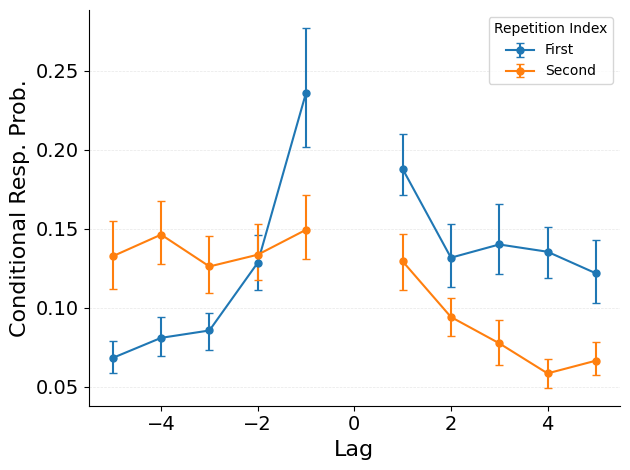

In [5]:
#| code-summary: Plot incoming repetition Lag-CRP
#| label: fig-cleanbackrepcrp
#| fig-cap: "Incoming repetition Lag-CRP for each presentation index of repeated items."
plot_back_rep_crp(
    data,
    trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="incoming")

---

## Reference

In [6]:
#| echo: false
show_doc(plot_back_rep_crp)

---

### plot_back_rep_crp

>      plot_back_rep_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],j
>                         axcmr.typing.RecallDataset], trial_masks:Union[Sequenc
>                         e[jaxtyping.Bool[Array,'trial_count']],jaxtyping.Bool[
>                         Array,'trial_count']], max_lag:int=5, min_lag:int=4,
>                         size:int=2, repetition_index:Optional[int]=None,
>                         color_cycle:Optional[list[str]]=None,
>                         labels:Optional[Sequence[str]]=None,
>                         contrast_name:Optional[str]=None,
>                         axis:Optional[matplotlib.axes._axes.Axes]=None,
>                         confidence_level:float=0.95)

*Plot incoming repetition lag-CRP with CIs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks to filter trials in datasets. |
| max_lag | int | 5 | Maximum lag to plot. |
| min_lag | int | 4 | Minimum separation between repeated<br>presentations. |
| size | int | 2 | Maximum study positions per item. |
| repetition_index | Optional | None | Specific repetition index to plot. |
| color_cycle | Optional | None | Colors for plotting each dataset. |
| labels | Optional | None | Labels for repetition-index lines. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Axes with the incoming repetition CRP plot.** |

In [7]:
ax = plot_back_rep_crp(data, trial_mask, max_lag=5, min_lag=4, size=2)
assert isinstance(ax, Axes)
plt.close()

In [8]:
#| echo: false
show_doc(subject_back_rep_crp)

---

### subject_back_rep_crp

>      subject_back_rep_crp (dataset:jaxcmr.typing.RecallDataset,
>                            trial_mask:jaxtyping.Bool[Array,'trial_count'],
>                            min_lag:int=4, max_lag:int=5, size:int=2)

*Compute subject-level incoming repetition CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Recall dataset. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials to include. |
| min_lag | int | 4 | Minimum spacing between item repetitions. |
| max_lag | int | 5 | Maximum lag to include in output. |
| size | int | 2 | Maximum presentations per item. |
| **Returns** | **ndarray** |  | **Shape ``(n_subjects, size, 2*max_lag+1)``.** |

In [9]:
import numpy as np

result = subject_back_rep_crp(data, trial_mask, min_lag=4, max_lag=5, size=2)
assert isinstance(result, np.ndarray)
assert result.ndim == 3
assert result.shape[1] == 2  # size
assert result.shape[2] == 11  # 2*max_lag+1

In [10]:
#| echo: false
show_doc(test_back_rep_crp_vs_control)

---

### test_back_rep_crp_vs_control

>      test_back_rep_crp_vs_control (observed_crp:numpy.ndarray,
>                                    control_crp:numpy.ndarray, max_lag:int=5)

*Test observed vs control backward CRP per index.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| max_lag | int | 5 | Maximum lag used for labeling. |
| **Returns** | **dict** |  |  |

In [11]:
results = test_back_rep_crp_vs_control(result, result, max_lag=5)
assert isinstance(results, dict)

In [12]:
#| echo: false
show_doc(test_first_second_bias)

---

### test_first_second_bias

>      test_first_second_bias (observed_crp:numpy.ndarray,
>                              control_crp:numpy.ndarray, max_lag:int=5)

*Test whether first-presentation bias differs.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| observed_crp | ndarray |  | Subject-level CRP from observed data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| control_crp | ndarray |  | Subject-level CRP from control data.<br>Shape ``(n_subjects, size, 2*max_lag+1)``. |
| max_lag | int | 5 | Maximum lag used for labeling. |
| **Returns** | **BackRepCRPTestResult** |  |  |

In [13]:
from jaxcmr.analyses.backrepcrp import BackRepCRPTestResult

bias_result = test_first_second_bias(result, result, max_lag=5)
assert isinstance(bias_result, BackRepCRPTestResult)